# EDA Notebook

## 1. Import the necessary libraries
Import pandas, numpy, matplotlib, and seaborn for data analysis and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium as fl
import nltk as nt


## 2. Upload the CSV file
Ask the user for the path to the .csv file and load it into a pandas DataFrame.

In [3]:
import os

# Change this path to point to your data file
file_path = 'data/raw/Hotel_Reviews.csv'

possible_paths = [
	file_path,
	'Hotel_Reviews.csv',
	'data/Hotel_Reviews.csv',
	'../data/raw/Hotel_Reviews.csv',
	'./data/raw/Hotel_Reviews.csv',
]

for path in possible_paths:
	if os.path.exists(path):
		file_path = path
		break

if not os.path.exists(file_path):
	raise FileNotFoundError(
		f"File not found: {file_path}. "
		"Please verify the dataset location or move the CSV to one of the expected paths."
	)

df = pd.read_csv(file_path)

## 3. View the first few rows of the dataset
Display the first few rows of the DataFrame using `head()` to get an overview of the data.

In [4]:
df.head(10)

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968
5,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,Poland,Backyard of the hotel is total mess shouldn t...,17,1403,Good restaurant with modern design great chil...,20,1,6.7,"[' Leisure trip ', ' Group ', ' Duplex Double ...",10 days,52.360576,4.915968
6,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/17/2017,7.7,Hotel Arena,United Kingdom,Cleaner did not change our sheet and duvet ev...,33,1403,The room is spacious and bright The hotel is ...,18,6,4.6,"[' Leisure trip ', ' Group ', ' Duplex Twin Ro...",17 days,52.360576,4.915968
7,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/17/2017,7.7,Hotel Arena,United Kingdom,Apart from the price for the brekfast Everyth...,11,1403,Good location Set in a lovely park friendly s...,19,1,10.0,"[' Leisure trip ', ' Couple ', ' Duplex Double...",17 days,52.360576,4.915968
8,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/9/2017,7.7,Hotel Arena,Belgium,Even though the pictures show very clean room...,34,1403,No Positive,0,3,6.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",25 days,52.360576,4.915968
9,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/8/2017,7.7,Hotel Arena,Norway,The aircondition makes so much noise and its ...,15,1403,The room was big enough and the bed is good T...,50,1,7.9,"[' Leisure trip ', ' Couple ', ' Large King Ro...",26 days,52.360576,4.915968


## 4. Explore general information about the dataset
Use `info()` and `shape` to display information about the number of rows, columns, and data types.

In [5]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  str    
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  str    
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  str    
 5   Reviewer_Nationality                        515738 non-null  str    
 6   Negative_Review                             515738 non-null  str    
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  str    
 10  Review_

## 5. Describe numerical and categorical variables
Use `describe()` for numerical variables and `value_counts()` for categorical variables.

In [ ]:
# Numerical variables
print(df.describe())
#obtenemos las 20 nacionalidades que más comentan
nationalities_most_commented = df['Reviewer_Nationality'].value_counts().head(20)

       Additional_Number_of_Scoring  Average_Score  \
count                 515738.000000  515738.000000   
mean                     498.081836       8.397487   
std                      500.538467       0.548048   
min                        1.000000       5.200000   
25%                      169.000000       8.100000   
50%                      341.000000       8.400000   
75%                      660.000000       8.800000   
max                     2682.000000       9.800000   

       Review_Total_Negative_Word_Counts  Total_Number_of_Reviews  \
count                      515738.000000            515738.000000   
mean                           18.539450              2743.743944   
std                            29.690831              2317.464868   
min                             0.000000                43.000000   
25%                             2.000000              1161.000000   
50%                             9.000000              2134.000000   
75%                           

## 6. Display null and duplicate values
Identify and display the number of null values and duplicate rows in the dataset.

In [7]:
# Null values
print("VALORES NULOS: \n",df.isnull().sum())

# Duplicated rows
print("REGISTROS DUPLICADOS ",df.duplicated().sum())

VALORES NULOS: 
 Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64
REGISTROS DUPLICADOS  526


## 7. Univariate analysis of numerical variables
Create histograms and box plots to analyze the distribution of numerical variables.

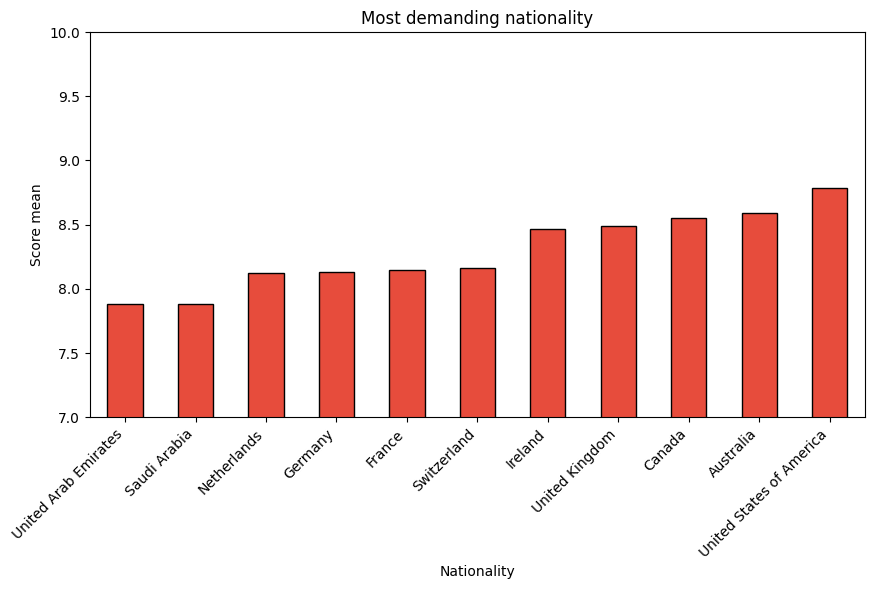

In [8]:
#Existe una relacion entre la nacionalidad del huesped y la nota que le pone al hotel?

#1.Las nacionalidades mas presentes en el dataset
df['Reviewer_Nationality'] = df['Reviewer_Nationality'].str.strip() #primero limpiamos los espacios en blanco
top_presents_nationalities = df['Reviewer_Nationality'].value_counts().head(11).index

#2.Filtramos el dataframe para quedarnos solamente con esas nacionalidades
df_top_countries = df[df['Reviewer_Nationality'].isin(top_presents_nationalities)]
most_negative_review = df_top_countries.groupby('Reviewer_Nationality')['Reviewer_Score'].mean().sort_values()#ordenamos por media

#3.Levantamos el grafico con matplotlib
plt.figure(figsize=(10, 5))
most_negative_review.plot(kind='bar', color='#e74c3c', edgecolor='black')

#4. Personalizamos el grafico
plt.title('Most demanding nationality')
plt.xlabel('Nationality')
plt.ylabel('Score mean')

plt.ylim(7, 10) #zoom para notar mas la diferencia
plt.xticks(rotation=45, ha='right') #giramos los nombres de los paises para que no se pisen
plt.tight_layout

plt.show() 

According to the chart, tourists from the United Arab Emirates give the lowest ratings, while Americans give the highest ratings. To understand these results, it is important to note that in cities like Dubai, luxury hotels meet standards that are likely higher than those of classic European luxury, so Emirati tourists tend to be more demanding. Furthermore, Saudi tourists are the second most demanding, which reinforces the high standards for luxury in the Middle East.

Let's find out why tourists in the United Arab Emirates are complaining:

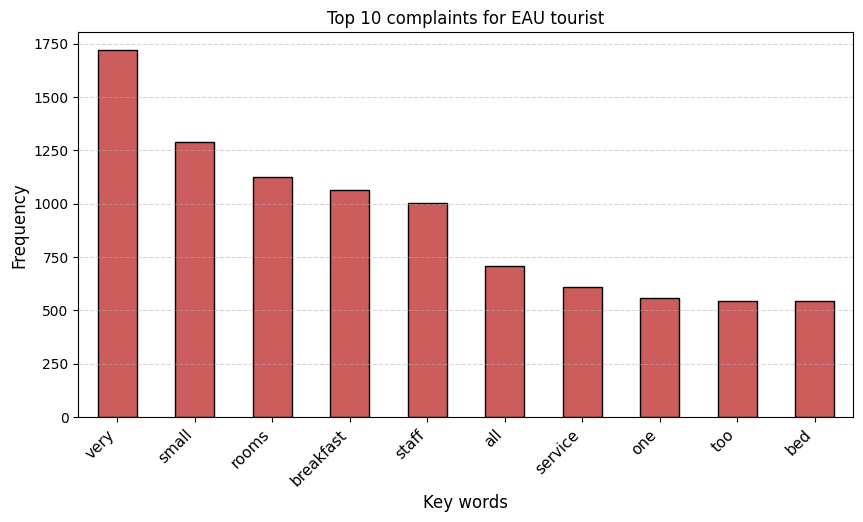

In [9]:
import re

df['Reviewer_Nationality'] = df['Reviewer_Nationality'].str.strip()

# 2. Creamos el filtro de los emiratíes AQUÍ MISMO para asegurar que tenga datos
df_eau = df[df['Reviewer_Nationality'] == 'United Arab Emirates']

#filtramos el dataframe para que solamente nos queden las filas de Emiratos.
complaint = " ".join(df_eau['Negative_Review'].astype(str).tolist()).lower() #bag of words. Unimos todas las palabras, y no separamos por filas
#Limpieza rapida de palabras, romper el texto en palabras sueltas
words = re.findall(r'\b[a-z]{3,}\b', complaint)
#palabras que no queremos
stopwords = {
    'the', 'and', 'was', 'not', 'for', 'with', 'but', 'room', 'hotel', 'nothing',
    'are','they', 'have', 'there', 'you', 'that', 'this', 'were', 'had', 'from', 'our', 'no', 'negative' 
}

#filtramos para quitar las palabras vacias de la linea
important_words = [p for p in words if p not in stopwords]

#cuales son las palabras que mas se repiten
top_complaint = pd.Series(important_words).value_counts().head(10)

plt.figure(figsize=(10, 5))

top_complaint.plot(kind='bar', color='indianred', edgecolor='black')
plt.title('Top 10 complaints for EAU tourist')
plt.xlabel('Key words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Looking at the words that appear most frequently in negative reviews from tourists in the United Arab Emirates, we see that terms such as SMALL, ROOMS, BREAKFAST, and SERVICE come up repeatedly. It’s clear that customers have issues with room size, breakfast, and even service. 

SEASONALITY OF COMPLAINTS.
Here, we want to see whether customers complain more in the summer or in the winter, so we can analyze what is going wrong at the hotels (problems with the air conditioning or heating, or staff who are overwhelmed or overburdened by excessive workloads).

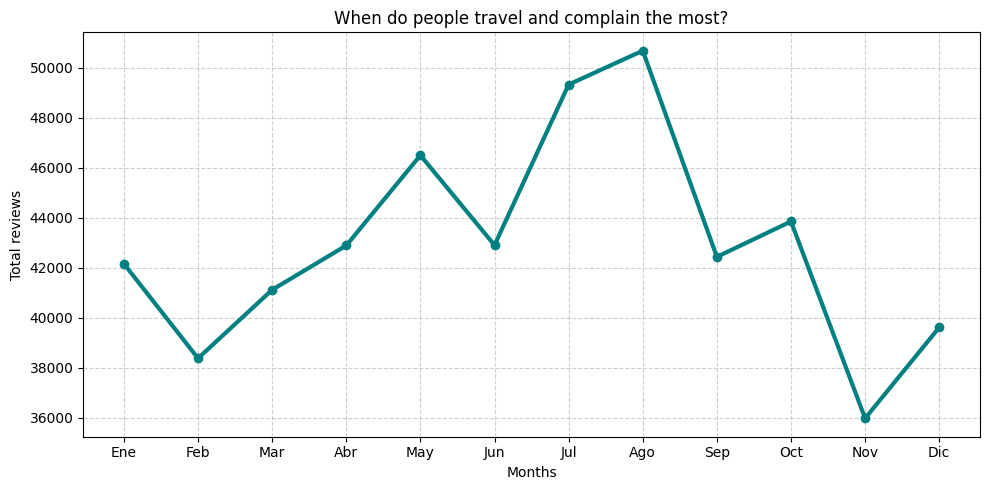

In [10]:
# 1. Convertir la columna de fechas a formato DateTime real de Pandas
df['Review_Date'] = pd.to_datetime(df['Review_Date'])

# 2. Extraer el número de mes (1 = Enero, 12 = Diciembre)
df['Month'] = df['Review_Date'].dt.month

# 3. Contar cuántas reviews (quejas) hay en cada mes del año y ordenarlos cronológicamente
month_complaints = df['Month'].value_counts().sort_index()

# 4. Mapear los números a nombres de meses 
months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
month_complaints.index = months

# 5. Dibujar el gráfico de líneas (ideal para ver el paso del tiempo o meses)
plt.figure(figsize=(10, 5))
plt.plot(month_complaints.index, month_complaints.values, marker='o', color='teal', linewidth=3)

# 6. Personalizar la estética
plt.title('When do people travel and complain the most?')
plt.xlabel('Months')
plt.ylabel('Total reviews')
plt.grid(True, linestyle='--', alpha=0.6) # Añadimos cuadrícula para ver mejor los picos
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Now, we’ll look at the complaints received during that time of year to see what customers were complaining about during the months with the highest number of complaints (as you can see, July and August) and gain a better understanding of the context.

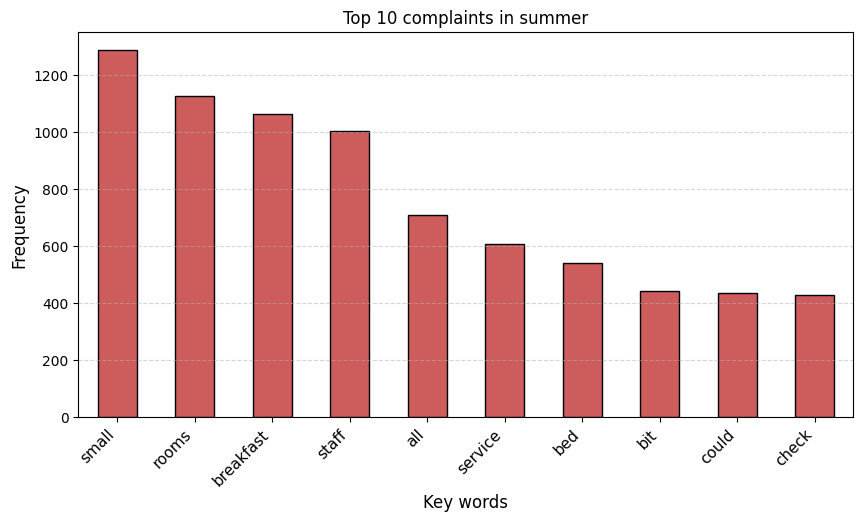

In [11]:
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Month'] = df['Review_Date'].dt.month #creamos columna nueva con solamente el mes

df_summer = df[df['Month'].isin([7,8])]#nos aseguramos de solo incluir los meses de julio y agosto

complaint_summer = " ".join(df_summer['Negative_Review'].astype(str).tolist()).lower() #juntamos todas las quejas en un bloque
words_summer = re.findall(r'\b[a-z]{3,}\b', complaint_summer) #aplicamos el regex

#palabras que no nos interesan
stopwords = {
        'the', 'and', 'was', 'not', 'for', 'with', 'but', 'room', 'hotel', 'nothing','when',
        'they', 'have', 'there', 'you', 'that', 'this', 'were', 'had', 'from', 'our', 'too'
        'all', 'very', 'one', 'would', 'about', 'good', 'get', 'been', 'location', 'are', 'no', 'negative',
        'too', 'like', 'which', 'out', 'bad', 'more'
    }

#filtramos para quitar las palabras vacias de la linea
important_words_summer = [p for p in words if p not in stopwords]

#cuales son las palabras que mas se repiten
top_complaint_summer = pd.Series(important_words_summer).value_counts().head(10)

#creamos el grafico
plt.figure(figsize=(10, 5))
top_complaint_summer.plot(kind='bar', color='indianred', edgecolor='black')
plt.title('Top 10 complaints in summer')
plt.xlabel('Key words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In summer, hotels reach peak occupancy. This often results in guests being assigned the most basic or smallest rooms available. Furthermore, with the high summer temperatures, the feeling of claustrophobia in confined spaces is magnified. Peak occupancy during the summer overwhelms the common areas. This results in long lines for breakfast, food running out quickly at the buffets, and delays in service from the staff.

## 8. Bivariate analysis of variables
Explore relationships between numerical and categorical variables using scatter plots and cross-tabulations.

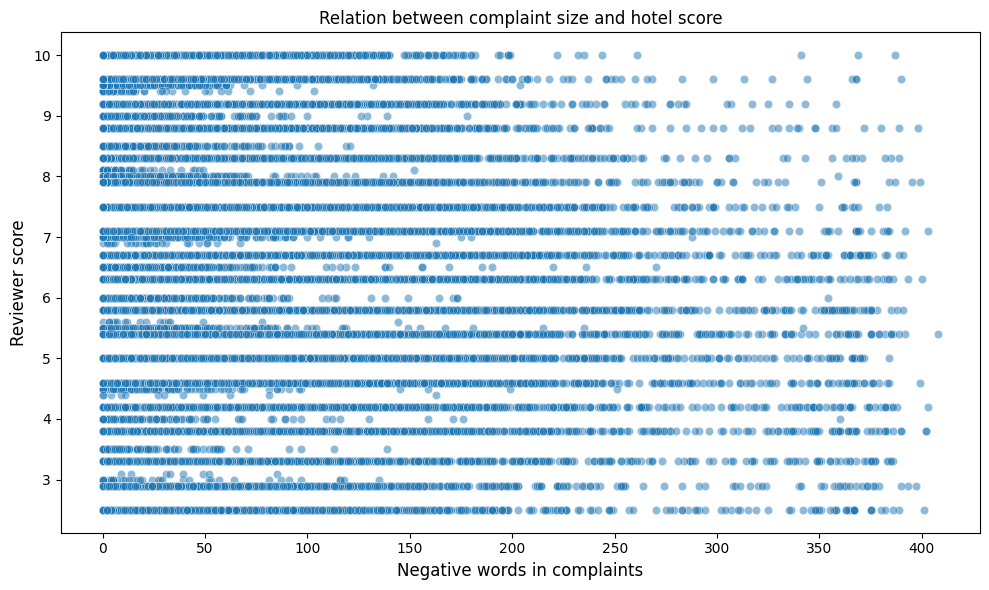

In [12]:
# Scatterplot. Longitud de la queja y la puntuacion del hotel. Veamos si hay algun tipo de relacion 

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Review_Total_Negative_Word_Counts', y='Reviewer_Score', alpha=0.5)

plt.title('Relation between complaint size and hotel score', fontsize=12)
plt.xlabel('Negative words in complaints', fontsize=12)
plt.ylabel('Reviewer score', fontsize=12)

plt.tight_layout()
plt.show()


This graph shows that there is a direct relationship between the rating a customer gives the hotel and the number of words in a review. On the left side of the graph (from 0 to 100 words), you can see that the lines and points are a deep, solid color. This means that, in general, reviews are short. This phenomenon can be observed in both positive and negative reviews. One could conclude that this is standard behavior. However, as we move to the right—that is, toward reviews with a higher word count—we see that at the top (where the reviews are positive), the dots become lighter and we can see blank spaces. This means that a satisfied person, who has rated the hotel higher than a seven, does not write such long reviews. In contrast, we can see that the lower the rating, the more time the customer spends writing their negative review. We can conclude that the more negative the review, the greater the customer’s need to explain their experience. They spend more time pointing out what is wrong.

## 9. Visualizing Correlations
Calculate and visualize the correlation matrix between numerical variables using a heatmap.

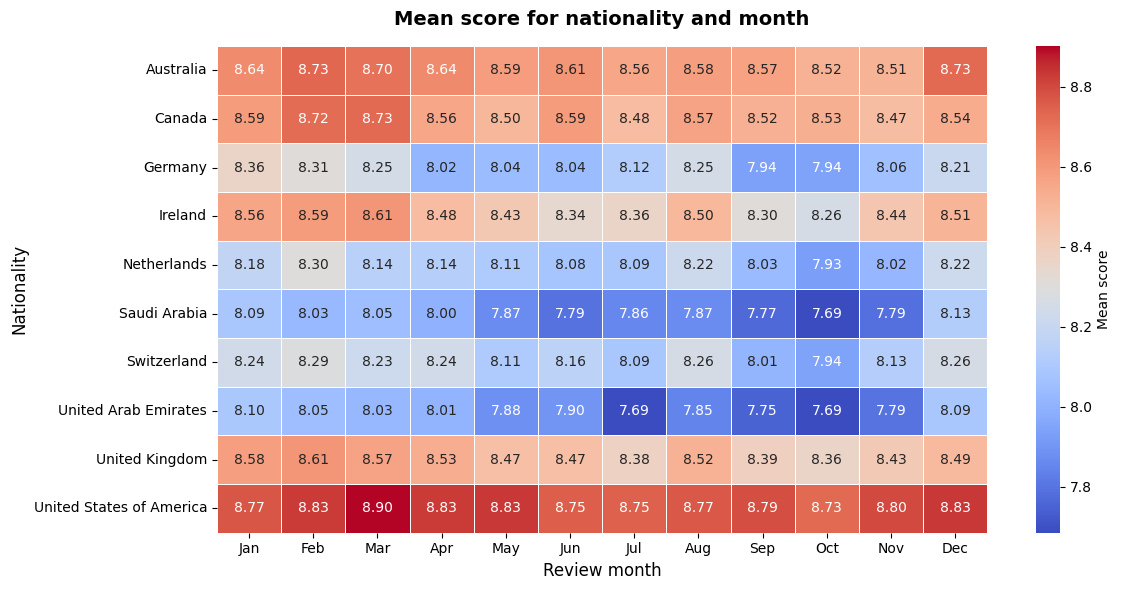

In [13]:
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Month'] = df['Review_Date'].dt.month

top_countries = df['Reviewer_Nationality'].value_counts().head(10).index
df_filtered = df[df['Reviewer_Nationality'].isin(top_countries)]
#necesitamos un pivot_table para calcular la puntuacion media, calculamos la media para ver los puntos negros de insatisfaccion
heat_matrix = df_filtered.pivot_table(
    values='Reviewer_Score', 
    index='Reviewer_Nationality', 
    columns='Month', 
    aggfunc='mean'
)

months_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] #cambiar al ingles
heat_matrix.columns = months_names
#creamos el mapa
plt.figure(figsize=(12,6))

sns.heatmap(
    heat_matrix, 
    cmap='coolwarm', 
    annot=True, 
    fmt=".2f", 
    linewidths=0.5,
    cbar_kws={'label': 'Mean score'}
)
#lo personalizamos
plt.title('Mean score for nationality and month', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Review month', fontsize=12)
plt.ylabel('Nationality', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


This graph shows the average scores from the 10 countries that leave the most reviews. We can see that Americans give the highest scores, with the highest peaks occurring in February, March, April, May, and December. We also see above-average scores in reviews from Australians and Canadians, and to a lesser extent, from Irish and British travelers. However, in the center of the map, we find nationalities such as Emiratis, Swiss, Saudis, and Dutch. For them, the experience at these hotels is worse, and this is clearly reflected in the average review score. We can see that the lowest scores occur during the summer months and in October, precisely when the high season ends and hotel staff levels are reduced. The very low score for this group may be due to hotels being overcrowded, staff service declining significantly, and infrastructure suffering, leading customers to feel that the price paid is excessive for what is offered.